# NBAForecast Final Analysis

This notebook summarizes the completed NBA forecasting project, including exploratory data analysis, chronological model evaluation, 2026-27 preseason record projections, 2027 postseason simulation probabilities, and final forecast conclusions.

## 1. Project Overview

The project uses historical NBA regular-season data from 2018-19 through 2025-26. The modeling dataset contains 9,509 regular-season games and 84 leakage-safe pregame features built from prior team performance only.

The 2025-26 season was held out as a completely unseen chronological evaluation season. After model selection, the final production model was retrained using all available games through 2025-26. The forecast target is the 2026-27 regular season and the 2027 playoffs.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d9e1ec",
    "axes.labelcolor": "#121826",
    "axes.titlecolor": "#121826",
    "xtick.color": "#263246",
    "ytick.color": "#263246",
    "font.size": 10,
    "axes.grid": True,
    "grid.color": "#e6ebf2",
    "grid.linewidth": 0.8,
})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

MODEL_DIR = Path("../models")
if not MODEL_DIR.exists():
    MODEL_DIR = Path("models")

GAMES_PATH = DATA_DIR / "nba_games_clean.csv"
FEATURES_PATH = DATA_DIR / "nba_features.csv"
EVALUATION_PATH = DATA_DIR / "model_evaluation.csv"
HOLDOUT_PATH = DATA_DIR / "holdout_predictions.csv"
SEASON_PATH = DATA_DIR / "season_2026_27_predictions.csv"
STANDINGS_PATH = DATA_DIR / "2027_projected_standings.csv"
PLAYOFFS_PATH = DATA_DIR / "2027_playoff_probabilities.csv"
SUMMARY_PATH = DATA_DIR / "forecast_2026_27_summary.json"
MODEL_PATH = MODEL_DIR / "nba_win_model.joblib"
FEATURE_COLUMNS_PATH = MODEL_DIR / "feature_columns.joblib"

for input_path in [
    GAMES_PATH,
    FEATURES_PATH,
    EVALUATION_PATH,
    HOLDOUT_PATH,
    SEASON_PATH,
    STANDINGS_PATH,
    PLAYOFFS_PATH,
    SUMMARY_PATH,
    MODEL_PATH,
    FEATURE_COLUMNS_PATH,
]:
    if not input_path.exists():
        raise FileNotFoundError(f"Missing required input file: {input_path}")

PROJECT_CONTEXT = pd.DataFrame(
    [
        ["Historical seasons", "2018-19 through 2025-26"],
        ["Regular-season games", "9,509"],
        ["Pregame feature count", "84"],
        ["Holdout evaluation season", "2025-26"],
        ["Forecast target", "2026-27 regular season and 2027 playoffs"],
    ],
    columns=["Item", "Value"],
)

PROJECT_CONTEXT

,Item,Value
0,Historical seasons,2018-19 through 2025-26
1,Regular-season games,"9,509"
2,Pregame feature count,84
3,Holdout evaluation season,2025-26
4,Forecast target,2026-27 regular season and 2027 playoffs


## 2. Data Overview

The exploratory work below uses the cleaned one-row-per-game file and the leakage-safe feature file already produced by the project pipeline. No source data is modified in this notebook.

In [2]:
games = pd.read_csv(GAMES_PATH, dtype={"GAME_ID": str}, parse_dates=["GAME_DATE"])
features = pd.read_csv(FEATURES_PATH, dtype={"GAME_ID": str}, parse_dates=["GAME_DATE"])

required_game_columns = [
    "GAME_ID",
    "GAME_DATE",
    "SEASON",
    "HOME_TEAM",
    "AWAY_TEAM",
    "HOME_PTS",
    "AWAY_PTS",
    "HOME_WIN",
]
missing_game_columns = sorted(set(required_game_columns) - set(games.columns))
if missing_game_columns:
    raise ValueError(f"Clean games file is missing columns: {missing_game_columns}")

required_feature_columns = [
    "GAME_ID",
    "GAME_DATE",
    "SEASON",
    "HOME_TEAM",
    "AWAY_TEAM",
    "HOME_WIN",
    "HOME_REST_DAYS",
    "AWAY_REST_DAYS",
    "HOME_BACK_TO_BACK",
    "AWAY_BACK_TO_BACK",
]
missing_feature_columns = sorted(set(required_feature_columns) - set(features.columns))
if missing_feature_columns:
    raise ValueError(f"Feature file is missing columns: {missing_feature_columns}")

games = games.sort_values(["GAME_DATE", "GAME_ID"]).reset_index(drop=True)
features = features.sort_values(["GAME_DATE", "GAME_ID"]).reset_index(drop=True)

games["TOTAL_POINTS"] = games["HOME_PTS"] + games["AWAY_PTS"]
games["TEAM_POINTS_PER_GAME"] = games["TOTAL_POINTS"] / 2
games["ABS_MARGIN"] = (games["HOME_PTS"] - games["AWAY_PTS"]).abs()

data_overview = pd.DataFrame(
    [
        ["Clean game rows", f"{len(games):,}"],
        ["Feature rows", f"{len(features):,}"],
        ["Unique games", f"{games['GAME_ID'].nunique():,}"],
        ["Seasons", f"{games['SEASON'].min()} through {games['SEASON'].max()}"],
        ["Date range", f"{games['GAME_DATE'].min().date()} to {games['GAME_DATE'].max().date()}"],
        ["Teams represented", f"{pd.concat([games['HOME_TEAM'], games['AWAY_TEAM']]).nunique()}"],
        ["Home-win rate", f"{games['HOME_WIN'].mean() * 100:.1f}%"],
        ["Average combined points", f"{games['TOTAL_POINTS'].mean():.1f}"],
        ["Median final margin", f"{games['ABS_MARGIN'].median():.1f} points"],
    ],
    columns=["Item", "Value"],
)

data_overview

,Item,Value
0,Clean game rows,"9,509"
1,Feature rows,"9,509"
2,Unique games,"9,509"
3,Seasons,2018-19 through 2025-26
4,Date range,2018-10-16 to 2026-04-12
5,Teams represented,30
6,Home-win rate,55.7%
7,Average combined points,226.1
8,Median final margin,10.0 points


## 3. Exploratory Data Analysis

These charts look at the basketball context behind the modeling task: home court, scoring environment, competitiveness, rest, and which pregame features the selected model uses most strongly.

### 3.1 Home-Court Advantage by Season

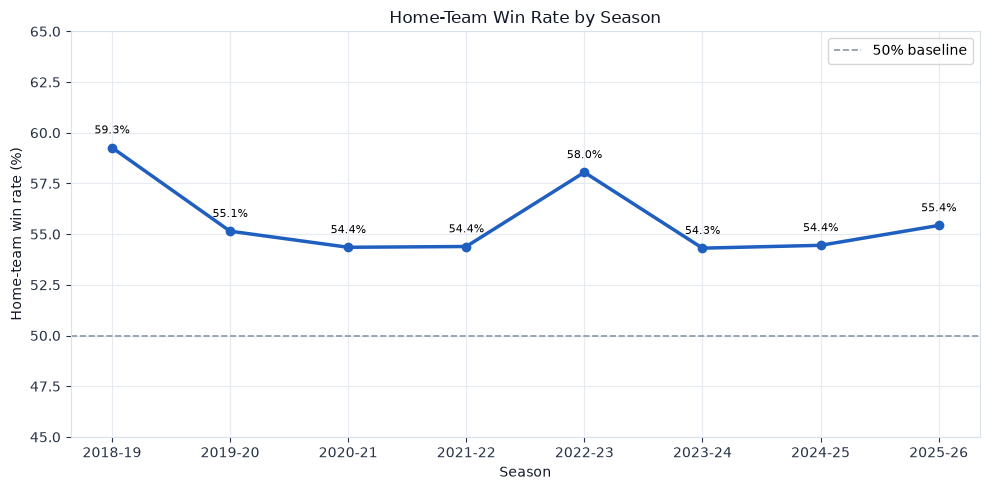

Home teams won **55.7%** of games overall. The season-level rate ranged from **54.3%** in **2023-24** to **59.3%** in **2018-19**. That baseline matters because the model predicts home-team win probability rather than a neutral matchup probability.

In [3]:
home_advantage = (
    games.groupby("SEASON", as_index=False)
    .agg(
        home_win_rate=("HOME_WIN", "mean"),
        games=("GAME_ID", "count"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    home_advantage["SEASON"],
    home_advantage["home_win_rate"] * 100,
    marker="o",
    linewidth=2.5,
    color="#1f5fbf",
)
ax.axhline(50, color="#8a96a8", linestyle="--", linewidth=1.2, label="50% baseline")
ax.set_title("Home-Team Win Rate by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home-team win rate (%)")
ax.set_ylim(45, max(65, home_advantage["home_win_rate"].max() * 100 + 3))
ax.legend()
for _, row in home_advantage.iterrows():
    ax.text(row["SEASON"], row["home_win_rate"] * 100 + 0.7, f"{row['home_win_rate'] * 100:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

lowest_home = home_advantage.loc[home_advantage["home_win_rate"].idxmin()]
highest_home = home_advantage.loc[home_advantage["home_win_rate"].idxmax()]
display(Markdown(
    f"Home teams won **{games['HOME_WIN'].mean() * 100:.1f}%** of games overall. "
    f"The season-level rate ranged from **{lowest_home['home_win_rate'] * 100:.1f}%** in **{lowest_home['SEASON']}** "
    f"to **{highest_home['home_win_rate'] * 100:.1f}%** in **{highest_home['SEASON']}**. "
    "That baseline matters because the model predicts home-team win probability rather than a neutral matchup probability."
))

### 3.2 Scoring Trends by Season

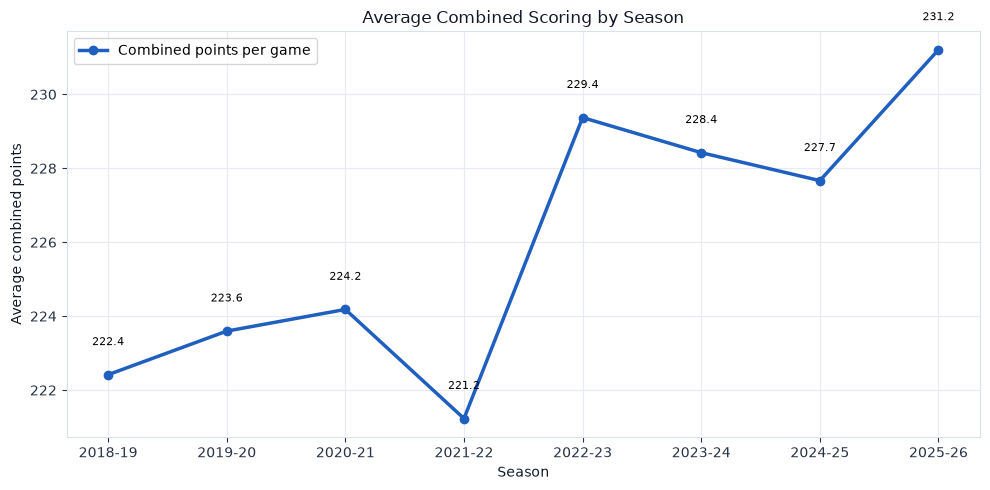

Average combined scoring moved from **222.4** points in **2018-19** to **231.2** in **2025-26**, with the highest mark at **231.2** in **2025-26**. This is useful context for rolling scoring features because the offensive environment is not perfectly static across seasons.

In [4]:
scoring_by_season = (
    games.groupby("SEASON", as_index=False)
    .agg(
        average_combined_points=("TOTAL_POINTS", "mean"),
        average_team_points=("TEAM_POINTS_PER_GAME", "mean"),
        games=("GAME_ID", "count"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    scoring_by_season["SEASON"],
    scoring_by_season["average_combined_points"],
    marker="o",
    linewidth=2.5,
    color="#1f5fbf",
    label="Combined points per game",
)
ax.set_title("Average Combined Scoring by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average combined points")
for _, row in scoring_by_season.iterrows():
    ax.text(row["SEASON"], row["average_combined_points"] + 0.8, f"{row['average_combined_points']:.1f}", ha="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

first_scoring = scoring_by_season.iloc[0]
last_scoring = scoring_by_season.iloc[-1]
peak_scoring = scoring_by_season.loc[scoring_by_season["average_combined_points"].idxmax()]
display(Markdown(
    f"Average combined scoring moved from **{first_scoring['average_combined_points']:.1f}** points in **{first_scoring['SEASON']}** "
    f"to **{last_scoring['average_combined_points']:.1f}** in **{last_scoring['SEASON']}**, with the highest mark at "
    f"**{peak_scoring['average_combined_points']:.1f}** in **{peak_scoring['SEASON']}**. "
    "This is useful context for rolling scoring features because the offensive environment is not perfectly static across seasons."
))

### 3.3 Game Competitiveness and Point Differential

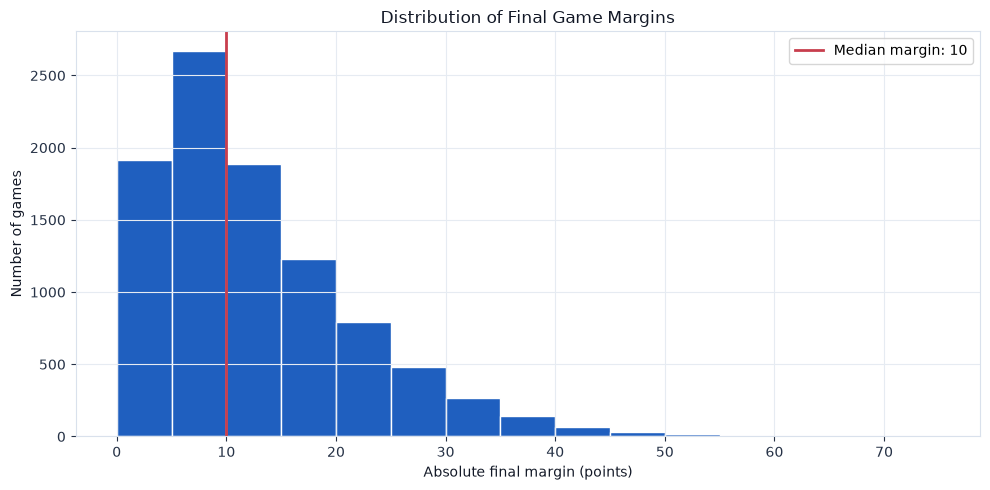

,Metric,Value
0,Median margin,10.0 points
1,Average margin,12.2 points
2,Games decided by 5 or fewer,25.8%
3,Games decided by 3 or fewer,14.7%


The typical game in this dataset was decided by **10** points, and **25.8%** of games finished within five points. The long right tail is a reminder that even a model with useful signal will face a lot of noisy, high-variance outcomes.

In [5]:
median_margin = games["ABS_MARGIN"].median()
mean_margin = games["ABS_MARGIN"].mean()
close_game_rate = games["ABS_MARGIN"].le(5).mean()
one_possession_rate = games["ABS_MARGIN"].le(3).mean()

bins = np.arange(0, games["ABS_MARGIN"].max() + 5, 5)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(games["ABS_MARGIN"], bins=bins, color="#1f5fbf", edgecolor="white")
ax.axvline(median_margin, color="#c83e4d", linewidth=2, label=f"Median margin: {median_margin:.0f}")
ax.set_title("Distribution of Final Game Margins")
ax.set_xlabel("Absolute final margin (points)")
ax.set_ylabel("Number of games")
ax.legend()
plt.tight_layout()
plt.show()

margin_summary = pd.DataFrame(
    [
        ["Median margin", f"{median_margin:.1f} points"],
        ["Average margin", f"{mean_margin:.1f} points"],
        ["Games decided by 5 or fewer", f"{close_game_rate * 100:.1f}%"],
        ["Games decided by 3 or fewer", f"{one_possession_rate * 100:.1f}%"],
    ],
    columns=["Metric", "Value"],
)
display(margin_summary)
display(Markdown(
    f"The typical game in this dataset was decided by **{median_margin:.0f}** points, and **{close_game_rate * 100:.1f}%** "
    "of games finished within five points. The long right tail is a reminder that even a model with useful signal will face a lot of noisy, high-variance outcomes."
))

### 3.4 Rest / Back-to-Back Analysis

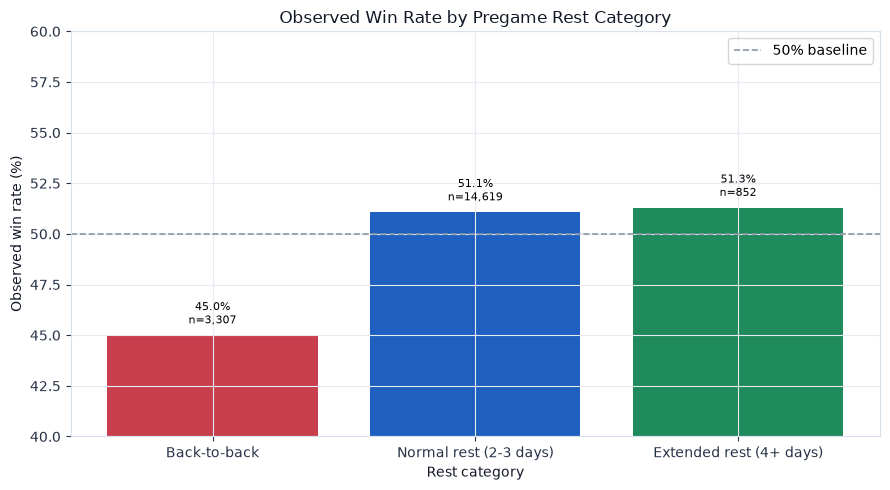

,REST_BUCKET,win_rate,team_games,average_rest_days
0,Back-to-back,0.450,3307,1.00
1,Normal rest (2-3 days),0.511,14619,2.19
2,Extended rest (4+ days),0.513,852,9.07


This is an observational split of team-game outcomes by pregame rest. The differences are modest and can be tangled with opponent quality, travel, and home/away scheduling, so the chart should be read as context rather than proof that rest caused the results.

In [6]:
home_rest = features[[
    "GAME_ID",
    "GAME_DATE",
    "SEASON",
    "HOME_TEAM",
    "HOME_WIN",
    "HOME_REST_DAYS",
    "HOME_BACK_TO_BACK",
]].rename(columns={
    "HOME_TEAM": "TEAM",
    "HOME_WIN": "WIN",
    "HOME_REST_DAYS": "REST_DAYS",
    "HOME_BACK_TO_BACK": "BACK_TO_BACK",
})
home_rest["IS_HOME"] = 1

away_rest = features[[
    "GAME_ID",
    "GAME_DATE",
    "SEASON",
    "AWAY_TEAM",
    "HOME_WIN",
    "AWAY_REST_DAYS",
    "AWAY_BACK_TO_BACK",
]].rename(columns={
    "AWAY_TEAM": "TEAM",
    "AWAY_REST_DAYS": "REST_DAYS",
    "AWAY_BACK_TO_BACK": "BACK_TO_BACK",
})
away_rest["WIN"] = 1 - away_rest["HOME_WIN"]
away_rest = away_rest.drop(columns="HOME_WIN")
away_rest["IS_HOME"] = 0

team_rest = pd.concat([home_rest, away_rest], ignore_index=True)
team_rest["REST_DAYS"] = pd.to_numeric(team_rest["REST_DAYS"], errors="coerce")
team_rest["BACK_TO_BACK"] = pd.to_numeric(team_rest["BACK_TO_BACK"], errors="coerce")

def rest_bucket(row):
    if pd.isna(row["REST_DAYS"]):
        return np.nan
    if row["BACK_TO_BACK"] == 1 or row["REST_DAYS"] == 1:
        return "Back-to-back"
    if row["REST_DAYS"] <= 3:
        return "Normal rest (2-3 days)"
    return "Extended rest (4+ days)"

team_rest["REST_BUCKET"] = team_rest.apply(rest_bucket, axis=1)
rest_order = ["Back-to-back", "Normal rest (2-3 days)", "Extended rest (4+ days)"]
rest_summary = (
    team_rest.dropna(subset=["REST_BUCKET"])
    .assign(REST_BUCKET=lambda frame: pd.Categorical(frame["REST_BUCKET"], categories=rest_order, ordered=True))
    .groupby("REST_BUCKET", observed=True)
    .agg(
        win_rate=("WIN", "mean"),
        team_games=("GAME_ID", "count"),
        average_rest_days=("REST_DAYS", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rest_summary["REST_BUCKET"].astype(str), rest_summary["win_rate"] * 100, color=["#c83e4d", "#1f5fbf", "#1f8a5b"])
ax.axhline(50, color="#8a96a8", linestyle="--", linewidth=1.2, label="50% baseline")
ax.set_title("Observed Win Rate by Pregame Rest Category")
ax.set_xlabel("Rest category")
ax.set_ylabel("Observed win rate (%)")
ax.set_ylim(40, 60)
ax.legend()
for bar, (_, row) in zip(bars, rest_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{row['win_rate'] * 100:.1f}%\nn={int(row['team_games']):,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

display(rest_summary.assign(win_rate=lambda frame: frame["win_rate"].round(3), average_rest_days=lambda frame: frame["average_rest_days"].round(2)))
display(Markdown(
    "This is an observational split of team-game outcomes by pregame rest. "
    "The differences are modest and can be tangled with opponent quality, travel, and home/away scheduling, so the chart should be read as context rather than proof that rest caused the results."
))

### 3.5 Feature / Model Insights

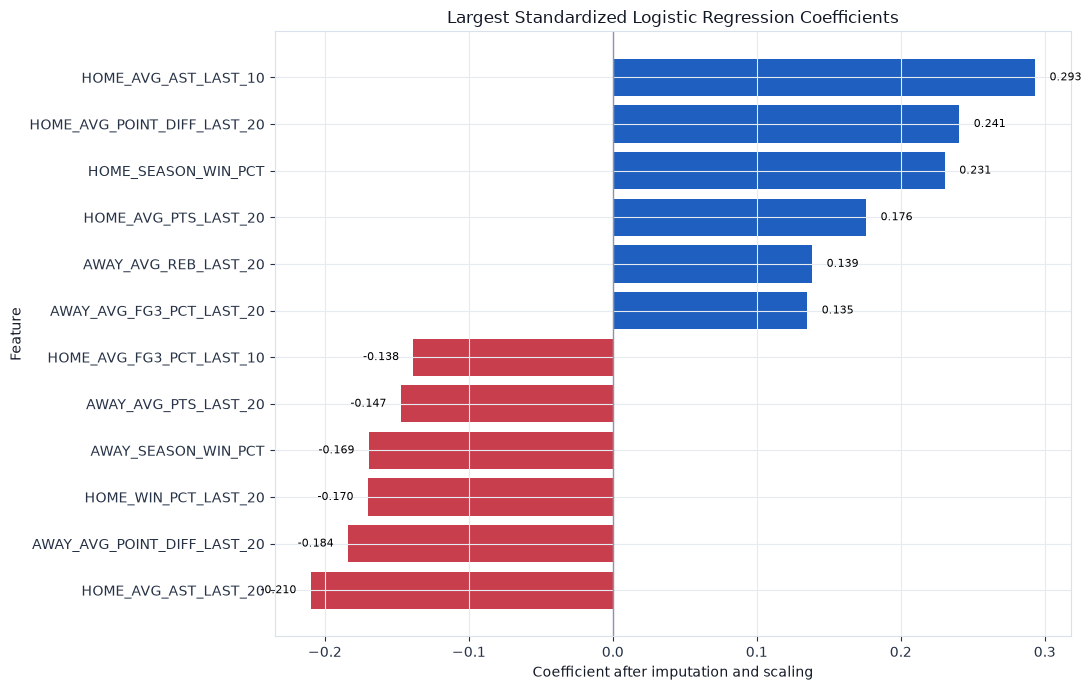

,feature,coefficient,absolute_coefficient
20,HOME_AVG_AST_LAST_10,0.2933,0.2933
27,HOME_AVG_POINT_DIFF_LAST_20,0.2407,0.2407
36,HOME_SEASON_WIN_PCT,0.2306,0.2306
32,HOME_AVG_AST_LAST_20,-0.2097,0.2097
69,AWAY_AVG_POINT_DIFF_LAST_20,-0.1838,0.1838
25,HOME_AVG_PTS_LAST_20,0.1760,0.1760
24,HOME_WIN_PCT_LAST_20,-0.1701,0.1701
78,AWAY_SEASON_WIN_PCT,-0.1694,0.1694
67,AWAY_AVG_PTS_LAST_20,-0.1472,0.1472
73,AWAY_AVG_REB_LAST_20,0.1385,0.1385


Because the production pipeline scales the numeric inputs, these coefficients are comparable on the model's standardized feature scale. Positive coefficients push predictions toward a home win, while negative coefficients push them away from a home win. These are model associations, not causal effects.

In [7]:
model_pipeline = joblib.load(MODEL_PATH)
feature_columns = joblib.load(FEATURE_COLUMNS_PATH)

if len(feature_columns) != 84:
    raise ValueError(f"Expected 84 feature columns, found {len(feature_columns)}.")
if "model" not in model_pipeline.named_steps:
    raise ValueError("Model pipeline is missing the Logistic Regression step named 'model'.")

coefficients = model_pipeline.named_steps["model"].coef_[0]
if len(coefficients) != len(feature_columns):
    raise ValueError("Coefficient count does not match feature column count.")

coefficient_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": coefficients,
})
coefficient_table["absolute_coefficient"] = coefficient_table["coefficient"].abs()
top_coefficients = coefficient_table.nlargest(12, "absolute_coefficient").sort_values("coefficient")

fig, ax = plt.subplots(figsize=(11, 7))
colors = np.where(top_coefficients["coefficient"].ge(0), "#1f5fbf", "#c83e4d")
ax.barh(top_coefficients["feature"], top_coefficients["coefficient"], color=colors)
ax.axvline(0, color="#8a96a8", linewidth=1)
ax.set_title("Largest Standardized Logistic Regression Coefficients")
ax.set_xlabel("Coefficient after imputation and scaling")
ax.set_ylabel("Feature")
for index, value in enumerate(top_coefficients["coefficient"]):
    label_position = value + (0.01 if value >= 0 else -0.01)
    ha = "left" if value >= 0 else "right"
    ax.text(label_position, index, f"{value:.3f}", va="center", ha=ha, fontsize=8)
plt.tight_layout()
plt.show()

display(top_coefficients.sort_values("absolute_coefficient", ascending=False).round(4))
display(Markdown(
    "Because the production pipeline scales the numeric inputs, these coefficients are comparable on the model's standardized feature scale. "
    "Positive coefficients push predictions toward a home win, while negative coefficients push them away from a home win. These are model associations, not causal effects."
))

## 4. Model Evaluation

The evaluation set is the full 2025-26 season. The table below compares the candidate models using accuracy, ROC AUC, Log Loss, and Brier Score.

Accuracy and ROC AUC are higher-is-better. Log Loss and Brier Score are lower-is-better, so they are charted separately instead of collapsed into a combined score.

In [8]:
evaluation = pd.read_csv(EVALUATION_PATH)
required_eval_columns = ["MODEL", "ACCURACY", "ROC_AUC", "LOG_LOSS", "BRIER_SCORE"]
missing_eval_columns = sorted(set(required_eval_columns) - set(evaluation.columns))
if missing_eval_columns:
    raise ValueError(f"Evaluation file is missing columns: {missing_eval_columns}")

evaluation_display = evaluation.copy()
evaluation_display[required_eval_columns[1:]] = evaluation_display[required_eval_columns[1:]].round(4)
evaluation_display


,MODEL,ACCURACY,ROC_AUC,LOG_LOSS,BRIER_SCORE
0,Logistic Regression,0.6629,0.7240,0.6102,0.2106
1,HistGradientBoosting,0.6669,0.7209,0.6132,0.2115
2,Random Forest,0.6588,0.7235,0.6146,0.2127
3,Dummy Baseline,0.5543,0.5000,0.6873,0.2471


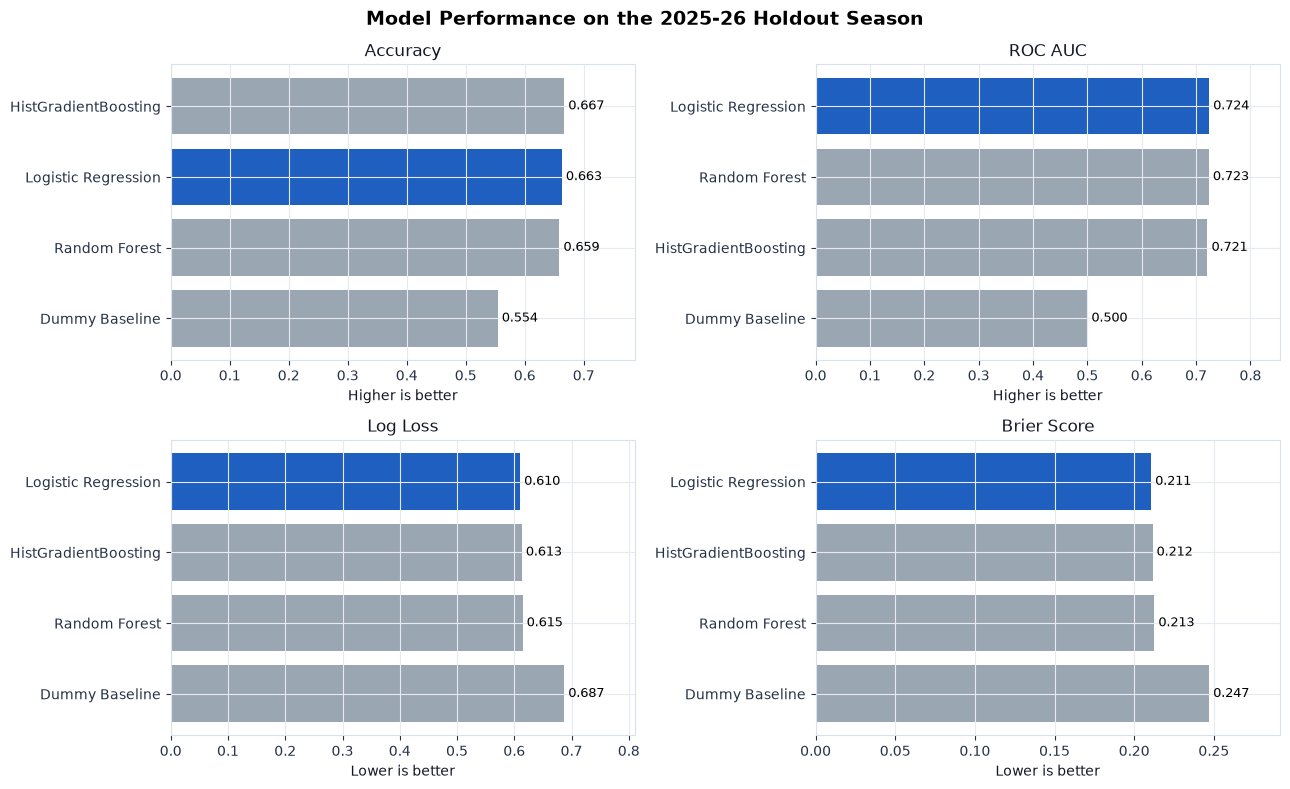

The comparison separates metrics by direction so the chart does not imply that every score should be maximized. Logistic Regression stands out on Log Loss and Brier Score, the two metrics most directly tied to probability quality.

In [9]:
metric_specs = [
    ("ACCURACY", "Accuracy", True),
    ("ROC_AUC", "ROC AUC", True),
    ("LOG_LOSS", "Log Loss", False),
    ("BRIER_SCORE", "Brier Score", False),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (metric, title, higher_is_better) in zip(axes, metric_specs):
    ordered = evaluation.sort_values(metric, ascending=not higher_is_better)
    colors = ["#1f5fbf" if model == "Logistic Regression" else "#9aa6b2" for model in ordered["MODEL"]]
    ax.barh(ordered["MODEL"], ordered[metric], color=colors)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Higher is better" if higher_is_better else "Lower is better")
    ax.set_xlim(0, ordered[metric].max() * 1.18)
    for index, value in enumerate(ordered[metric]):
        ax.text(value, index, f" {value:.3f}", va="center", fontsize=9)

fig.suptitle("Model Performance on the 2025-26 Holdout Season", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

display(Markdown(
    "The comparison separates metrics by direction so the chart does not imply that every score should be maximized. "
    "Logistic Regression stands out on Log Loss and Brier Score, the two metrics most directly tied to probability quality."
))

In [10]:

model_notes = []
for _, row in evaluation.iterrows():
    model = row["MODEL"]
    metrics = (
        f"Accuracy {row['ACCURACY']:.3f}, ROC AUC {row['ROC_AUC']:.3f}, "
        f"Log Loss {row['LOG_LOSS']:.3f}, Brier Score {row['BRIER_SCORE']:.3f}"
    )

    if model == "Logistic Regression":
        interpretation = (
            "selected because it produced the strongest probability-quality results, "
            "which matters most for downstream simulation."
        )
    elif model == "HistGradientBoosting":
        interpretation = (
            "had the highest accuracy, but its Log Loss and Brier Score were weaker "
            "than Logistic Regression."
        )
    elif model == "Random Forest":
        interpretation = (
            "was competitive on ROC AUC, but its probability-quality metrics trailed "
            "the selected model."
        )
    elif model == "Dummy Baseline":
        interpretation = (
            "sets the baseline by predicting the prior class distribution and confirms "
            "that the trained models add meaningful signal."
        )
    else:
        interpretation = "included for comparison."

    model_notes.append(f"- **{model}:** {metrics}; {interpretation}")

display(Markdown("### Model-by-model interpretation\n" + "\n".join(model_notes)))


### Model-by-model interpretation
- **Logistic Regression:** Accuracy 0.663, ROC AUC 0.724, Log Loss 0.610, Brier Score 0.211; selected because it produced the strongest probability-quality results, which matters most for downstream simulation.
- **HistGradientBoosting:** Accuracy 0.667, ROC AUC 0.721, Log Loss 0.613, Brier Score 0.212; had the highest accuracy, but its Log Loss and Brier Score were weaker than Logistic Regression.
- **Random Forest:** Accuracy 0.659, ROC AUC 0.723, Log Loss 0.615, Brier Score 0.213; was competitive on ROC AUC, but its probability-quality metrics trailed the selected model.
- **Dummy Baseline:** Accuracy 0.554, ROC AUC 0.500, Log Loss 0.687, Brier Score 0.247; sets the baseline by predicting the prior class distribution and confirms that the trained models add meaningful signal.

In [11]:
logistic_row = evaluation.loc[evaluation["MODEL"].eq("Logistic Regression")]
if logistic_row.empty:
    raise ValueError("Logistic Regression row not found in model evaluation file.")
logistic_row = logistic_row.iloc[0]

best_log_loss = evaluation.loc[evaluation["LOG_LOSS"].idxmin()]
best_brier = evaluation.loc[evaluation["BRIER_SCORE"].idxmin()]

display(Markdown(
    f"""
**Selected model:** Logistic Regression. It was selected primarily because it produced the best probability-quality metrics on the unseen 2025-26 holdout: Log Loss **{logistic_row['LOG_LOSS']:.3f}** and Brier Score **{logistic_row['BRIER_SCORE']:.3f}**. Its Accuracy was **{logistic_row['ACCURACY']:.3f}** and ROC AUC was **{logistic_row['ROC_AUC']:.3f}**.

Log Loss and Brier Score matter here because the predicted probabilities feed the Monte Carlo postseason simulator. A model that produces better-calibrated probabilities is more useful for simulation than a model selected only for classification accuracy.

Lowest Log Loss: **{best_log_loss['MODEL']}** ({best_log_loss['LOG_LOSS']:.3f}). Lowest Brier Score: **{best_brier['MODEL']}** ({best_brier['BRIER_SCORE']:.3f}).
"""
))



**Selected model:** Logistic Regression. It was selected primarily because it produced the best probability-quality metrics on the unseen 2025-26 holdout: Log Loss **0.610** and Brier Score **0.211**. Its Accuracy was **0.663** and ROC AUC was **0.724**.

Log Loss and Brier Score matter here because the predicted probabilities feed the Monte Carlo postseason simulator. A model that produces better-calibrated probabilities is more useful for simulation than a model selected only for classification accuracy.

Lowest Log Loss: **Logistic Regression** (0.610). Lowest Brier Score: **Logistic Regression** (0.211).


## 5. Calibration Analysis

Calibration checks whether games assigned similar predicted probabilities actually win at similar rates. In this project, calibration matters because the game probabilities feed the postseason simulation.

In [12]:
holdout = pd.read_csv(HOLDOUT_PATH, dtype={"GAME_ID": str}, parse_dates=["GAME_DATE"])
required_holdout_columns = ["GAME_ID", "GAME_DATE", "HOME_TEAM", "AWAY_TEAM", "HOME_WIN"]
missing_holdout_columns = sorted(set(required_holdout_columns) - set(holdout.columns))
if missing_holdout_columns:
    raise ValueError(f"Holdout prediction file is missing columns: {missing_holdout_columns}")

probability_columns = [column for column in holdout.columns if column.endswith("_HOME_WIN_PROB")]
logistic_probability_columns = [
    column for column in probability_columns
    if "LOGISTIC" in column.upper() and "REGRESSION" in column.upper()
]
if len(logistic_probability_columns) != 1:
    raise ValueError(
        "Expected exactly one Logistic Regression probability column. "
        f"Candidates found: {logistic_probability_columns}"
    )

lr_probability_column = logistic_probability_columns[0]
holdout["LR_HOME_WIN_PROB"] = holdout[lr_probability_column]
holdout["PREDICTED_HOME_WIN"] = (holdout["LR_HOME_WIN_PROB"] >= 0.50).astype(int)
holdout["THRESHOLD_CORRECT"] = holdout["PREDICTED_HOME_WIN"].eq(holdout["HOME_WIN"])
holdout["PREDICTED_WINNER"] = np.where(
    holdout["PREDICTED_HOME_WIN"].eq(1),
    holdout["HOME_TEAM"],
    holdout["AWAY_TEAM"],
)
holdout["WINNING_PROBABILITY"] = np.where(
    holdout["PREDICTED_HOME_WIN"].eq(1),
    holdout["LR_HOME_WIN_PROB"],
    1 - holdout["LR_HOME_WIN_PROB"],
)
holdout["DISTANCE_FROM_50"] = (holdout["LR_HOME_WIN_PROB"] - 0.50).abs()

holdout_summary = pd.DataFrame(
    [
        ["Logistic Regression probability column", lr_probability_column],
        ["Holdout games", f"{len(holdout):,}"],
        ["Average predicted home-win probability", f"{holdout['LR_HOME_WIN_PROB'].mean():.3f}"],
        ["Actual home-win rate", f"{holdout['HOME_WIN'].mean():.3f}"],
        ["Thresholded accuracy at 0.50", f"{holdout['THRESHOLD_CORRECT'].mean():.3f}"],
    ],
    columns=["Metric", "Value"],
)

print(f"Prepared {len(holdout):,} holdout predictions using {lr_probability_column}.")

Prepared 1,225 holdout predictions using LOGISTIC_REGRESSION_HOME_WIN_PROB.


,PROBABILITY_BIN,average_predicted_probability,actual_home_win_rate,number_of_games
0,"(-0.001, 0.1]",0.074,0.000,2
1,"(0.1, 0.2]",0.167,0.194,31
2,"(0.2, 0.3]",0.257,0.244,86
3,"(0.3, 0.4]",0.351,0.294,136
4,"(0.4, 0.5]",0.452,0.469,192
5,"(0.5, 0.6]",0.551,0.555,245
6,"(0.6, 0.7]",0.650,0.633,251
7,"(0.7, 0.8]",0.746,0.785,177
8,"(0.8, 0.9]",0.842,0.824,91
9,"(0.9, 1.0]",0.919,0.929,14


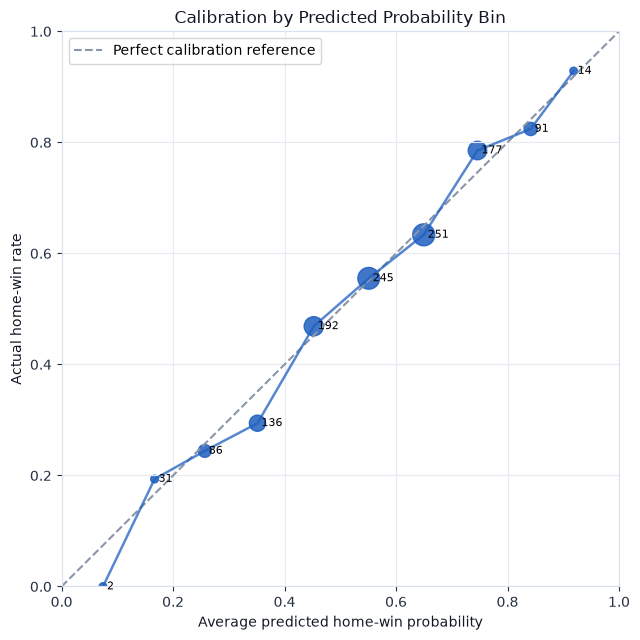

A well-calibrated model would place the blue points close to the dashed y=x line. Here, the average absolute gap across populated bins is **0.027**. The model is useful for probability-driven simulation, but the bins show that it is not perfectly calibrated.

In [13]:
calibration_bins = np.linspace(0, 1, 11)
holdout["PROBABILITY_BIN"] = pd.cut(
    holdout["LR_HOME_WIN_PROB"],
    bins=calibration_bins,
    include_lowest=True,
)

calibration = (
    holdout.groupby("PROBABILITY_BIN", observed=True)
    .agg(
        average_predicted_probability=("LR_HOME_WIN_PROB", "mean"),
        actual_home_win_rate=("HOME_WIN", "mean"),
        number_of_games=("GAME_ID", "count"),
    )
    .reset_index()
)

calibration_display = calibration.copy()
calibration_display["PROBABILITY_BIN"] = calibration_display["PROBABILITY_BIN"].astype(str)
display(calibration_display.round(3))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], color="#8a96a8", linestyle="--", label="Perfect calibration reference")
ax.plot(
    calibration["average_predicted_probability"],
    calibration["actual_home_win_rate"],
    color="#1f5fbf",
    linewidth=1.8,
    alpha=0.75,
)
ax.scatter(
    calibration["average_predicted_probability"],
    calibration["actual_home_win_rate"],
    s=np.maximum(calibration["number_of_games"], 30),
    color="#1f5fbf",
    alpha=0.85,
)
for _, row in calibration.iterrows():
    ax.text(
        row["average_predicted_probability"],
        row["actual_home_win_rate"],
        f" {int(row['number_of_games'])}",
        va="center",
        fontsize=8,
    )
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Average predicted home-win probability")
ax.set_ylabel("Actual home-win rate")
ax.set_title("Calibration by Predicted Probability Bin")
ax.legend()
plt.tight_layout()
plt.show()

mean_abs_calibration_error = (
    calibration["average_predicted_probability"] - calibration["actual_home_win_rate"]
).abs().mean()
display(Markdown(
    "A well-calibrated model would place the blue points close to the dashed y=x line. "
    f"Here, the average absolute gap across populated bins is **{mean_abs_calibration_error:.3f}**. "
    "The model is useful for probability-driven simulation, but the bins show that it is not perfectly calibrated."
))

## 6. Holdout Prediction Analysis

The next section analyzes the final Logistic Regression probabilities on the unseen 2025-26 holdout season. The probability column is detected automatically from the holdout prediction file.

In [14]:
holdout_summary

,Metric,Value
0,Logistic Regression probability column,LOGISTIC_REGRESSION_HOME_WIN_PROB
1,Holdout games,"1,225"
2,Average predicted home-win probability,0.556
3,Actual home-win rate,0.554
4,Thresholded accuracy at 0.50,0.663


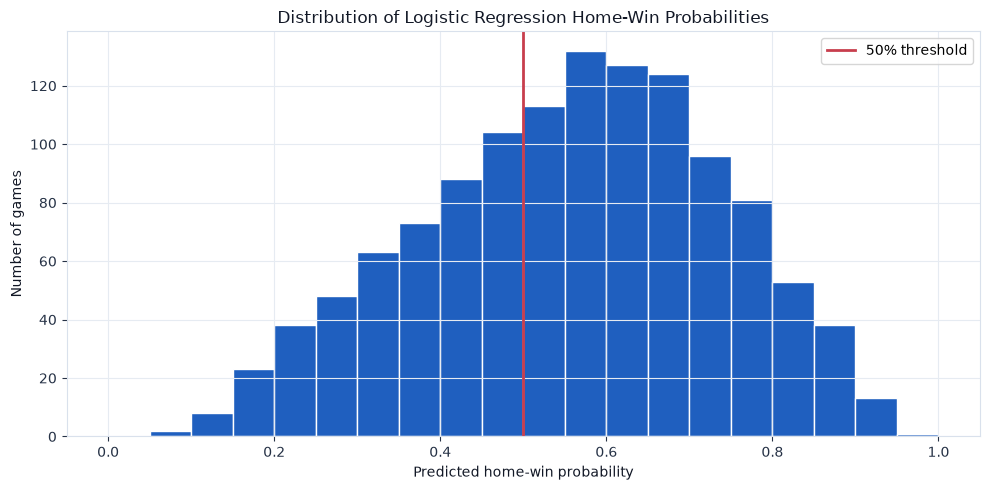

The average predicted home-win probability was **0.556**, close to the actual holdout home-win rate of **0.554**. Most predictions stay near the middle, which is reasonable for NBA games where many matchups are competitive.

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(holdout["LR_HOME_WIN_PROB"], bins=np.linspace(0, 1, 21), color="#1f5fbf", edgecolor="white")
ax.axvline(0.50, color="#c83e4d", linewidth=2, label="50% threshold")
ax.set_title("Distribution of Logistic Regression Home-Win Probabilities")
ax.set_xlabel("Predicted home-win probability")
ax.set_ylabel("Number of games")
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown(
    f"The average predicted home-win probability was **{holdout['LR_HOME_WIN_PROB'].mean():.3f}**, "
    f"close to the actual holdout home-win rate of **{holdout['HOME_WIN'].mean():.3f}**. "
    "Most predictions stay near the middle, which is reasonable for NBA games where many matchups are competitive."
))

In [16]:
highest_confidence = holdout.sort_values(
    ["WINNING_PROBABILITY", "DISTANCE_FROM_50"],
    ascending=[False, False],
).head(10)[
    [
        "GAME_DATE",
        "AWAY_TEAM",
        "HOME_TEAM",
        "HOME_WIN",
        "LR_HOME_WIN_PROB",
        "PREDICTED_WINNER",
        "WINNING_PROBABILITY",
        "THRESHOLD_CORRECT",
    ]
]

closest_to_50 = holdout.sort_values(
    ["DISTANCE_FROM_50", "GAME_DATE", "GAME_ID"],
    ascending=[True, True, True],
).head(10)[
    [
        "GAME_DATE",
        "AWAY_TEAM",
        "HOME_TEAM",
        "HOME_WIN",
        "LR_HOME_WIN_PROB",
        "PREDICTED_WINNER",
        "WINNING_PROBABILITY",
        "THRESHOLD_CORRECT",
    ]
]

display(Markdown("### Highest-confidence holdout predictions"))
display(highest_confidence.round({"LR_HOME_WIN_PROB": 3, "WINNING_PROBABILITY": 3}))

display(Markdown("### Closest-to-50% holdout predictions"))
display(closest_to_50.round({"LR_HOME_WIN_PROB": 3, "WINNING_PROBABILITY": 3}))


### Highest-confidence holdout predictions

,GAME_DATE,AWAY_TEAM,HOME_TEAM,HOME_WIN,LR_HOME_WIN_PROB,PREDICTED_WINNER,WINNING_PROBABILITY,THRESHOLD_CORRECT
33,2025-10-26,BKN,SAS,1,0.952,SAS,0.952,True
830,2026-02-20,BKN,OKC,1,0.934,OKC,0.934,True
386,2025-12-18,LAC,OKC,1,0.930,OKC,0.930,True
23,2025-10-24,SAS,NOP,0,0.073,SAS,0.927,True
492,2025-12-31,POR,OKC,1,0.926,OKC,0.926,True
204,2025-11-17,OKC,NOP,0,0.076,OKC,0.924,True
85,2025-11-02,NOP,OKC,1,0.923,OKC,0.923,True
166,2025-11-12,WAS,HOU,1,0.921,HOU,0.921,True
664,2026-01-23,IND,OKC,0,0.917,OKC,0.917,False
1057,2026-03-22,WAS,NYK,1,0.916,NYK,0.916,True


### Closest-to-50% holdout predictions

,GAME_DATE,AWAY_TEAM,HOME_TEAM,HOME_WIN,LR_HOME_WIN_PROB,PREDICTED_WINNER,WINNING_PROBABILITY,THRESHOLD_CORRECT
51,2025-10-27,MEM,GSW,1,0.500,MEM,0.500,False
84,2025-11-01,HOU,BOS,0,0.501,BOS,0.501,False
1030,2026-03-18,LAL,HOU,0,0.501,HOU,0.501,False
792,2026-02-09,PHI,POR,1,0.502,POR,0.502,True
507,2026-01-02,MEM,LAL,1,0.502,LAL,0.502,True
892,2026-03-01,MIL,CHI,1,0.502,CHI,0.502,True
940,2026-03-07,LAC,MEM,0,0.502,MEM,0.502,False
536,2026-01-06,LAL,NOP,0,0.502,NOP,0.502,False
769,2026-02-07,WAS,BKN,1,0.503,BKN,0.503,True
1157,2026-04-05,WAS,BKN,1,0.497,WAS,0.503,False


## 7. 2026-27 Season Projections

These are team-strength estimates for an 82-game season. They are not full simulations of the official 2026-27 schedule.

In [17]:
season = pd.read_csv(SEASON_PATH)
required_season_columns = ["TEAM", "PROJECTED_WINS", "PROJECTED_LOSSES", "PROJECTED_WIN_PCT"]
missing_season_columns = sorted(set(required_season_columns) - set(season.columns))
if missing_season_columns:
    raise ValueError(f"Season projection file is missing columns: {missing_season_columns}")

season_sorted = season.sort_values(
    ["PROJECTED_WINS", "PROJECTED_WIN_PCT", "TEAM"],
    ascending=[False, False, True],
).reset_index(drop=True)

top_team_row = season_sorted.iloc[0]
top_5_records = season_sorted.head(5).copy()

display(season_sorted)
display(Markdown(
    f"Highest projected team: **{top_team_row['TEAM']}** with **{int(top_team_row['PROJECTED_WINS'])}** projected wins."
))
display(Markdown("### Top 5 projected records"))
display(top_5_records)


,TEAM,PROJECTED_WINS,PROJECTED_LOSSES,PROJECTED_WIN_PCT
0,SAS,59,23,0.719512
1,OKC,58,24,0.707317
2,DET,56,26,0.682927
3,BOS,53,29,0.646341
4,DEN,53,29,0.646341
5,CHA,52,30,0.634146
6,TOR,51,31,0.621951
7,CLE,50,32,0.609756
8,HOU,50,32,0.609756
9,NYK,50,32,0.609756


Highest projected team: **SAS** with **59** projected wins.

### Top 5 projected records

,TEAM,PROJECTED_WINS,PROJECTED_LOSSES,PROJECTED_WIN_PCT
0,SAS,59,23,0.719512
1,OKC,58,24,0.707317
2,DET,56,26,0.682927
3,BOS,53,29,0.646341
4,DEN,53,29,0.646341


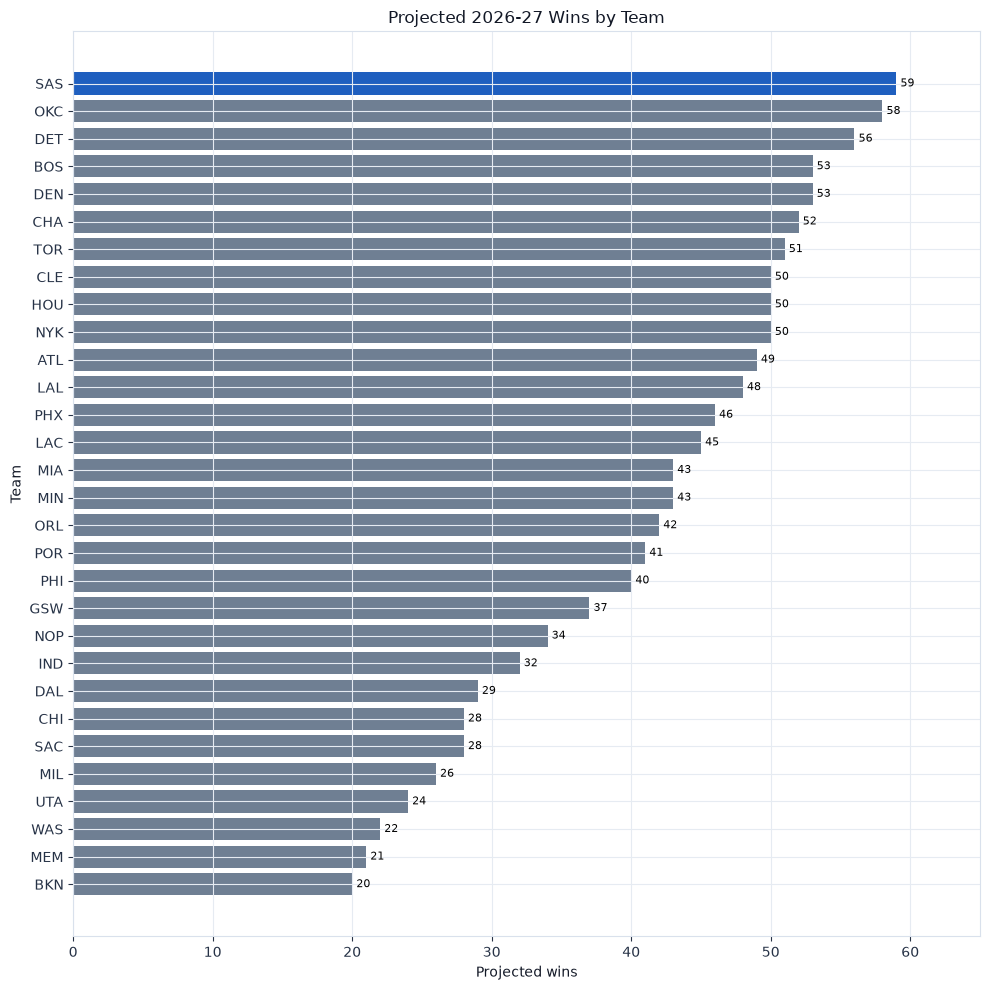

In [18]:
plot_rows = season_sorted.sort_values("PROJECTED_WINS", ascending=True)
fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#1f5fbf" if team == top_team_row["TEAM"] else "#6f7f93" for team in plot_rows["TEAM"]]
ax.barh(plot_rows["TEAM"], plot_rows["PROJECTED_WINS"], color=colors)
ax.set_title("Projected 2026-27 Wins by Team")
ax.set_xlabel("Projected wins")
ax.set_ylabel("Team")
for index, value in enumerate(plot_rows["PROJECTED_WINS"]):
    ax.text(value + 0.3, index, f"{int(value)}", va="center", fontsize=8)
ax.set_xlim(0, max(plot_rows["PROJECTED_WINS"]) + 6)
plt.tight_layout()
plt.show()


## 8. Conference Standings

The projected standings file contains seeds 1-10 for each conference. Seeds 1-6 are direct playoff positions, while seeds 7-10 feed the Play-In simulation.

In [19]:
standings = pd.read_csv(STANDINGS_PATH)
required_standings_columns = [
    "CONFERENCE",
    "SEED",
    "TEAM",
    "PROJECTED_WINS",
    "PROJECTED_LOSSES",
    "PROJECTED_WIN_PCT",
]
missing_standings_columns = sorted(set(required_standings_columns) - set(standings.columns))
if missing_standings_columns:
    raise ValueError(f"Projected standings file is missing columns: {missing_standings_columns}")

for conference in ["Eastern", "Western"]:
    display(Markdown(f"### {conference} Conference projected seeds"))
    display(
        standings.loc[standings["CONFERENCE"].eq(conference), required_standings_columns]
        .sort_values("SEED")
        .reset_index(drop=True)
    )

conference_leaders = (
    standings.sort_values(["CONFERENCE", "SEED"])
    .groupby("CONFERENCE", as_index=False)
    .first()[["CONFERENCE", "TEAM", "PROJECTED_WINS", "PROJECTED_LOSSES", "PROJECTED_WIN_PCT"]]
)
display(Markdown("### Strongest projected team by conference"))
display(conference_leaders)


### Eastern Conference projected seeds

,CONFERENCE,SEED,TEAM,PROJECTED_WINS,PROJECTED_LOSSES,PROJECTED_WIN_PCT
0,Eastern,1,DET,56,26,0.682927
1,Eastern,2,BOS,53,29,0.646341
2,Eastern,3,CHA,52,30,0.634146
3,Eastern,4,TOR,51,31,0.621951
4,Eastern,5,CLE,50,32,0.609756
5,Eastern,6,NYK,50,32,0.609756
6,Eastern,7,ATL,49,33,0.597561
7,Eastern,8,MIA,43,39,0.524390
8,Eastern,9,ORL,42,40,0.512195
9,Eastern,10,PHI,40,42,0.487805


### Western Conference projected seeds

,CONFERENCE,SEED,TEAM,PROJECTED_WINS,PROJECTED_LOSSES,PROJECTED_WIN_PCT
0,Western,1,SAS,59,23,0.719512
1,Western,2,OKC,58,24,0.707317
2,Western,3,DEN,53,29,0.646341
3,Western,4,HOU,50,32,0.609756
4,Western,5,LAL,48,34,0.585366
5,Western,6,PHX,46,36,0.560976
6,Western,7,LAC,45,37,0.548780
7,Western,8,MIN,43,39,0.524390
8,Western,9,POR,41,41,0.500000
9,Western,10,GSW,37,45,0.451220


### Strongest projected team by conference

,CONFERENCE,TEAM,PROJECTED_WINS,PROJECTED_LOSSES,PROJECTED_WIN_PCT
0,Eastern,DET,56,26,0.682927
1,Western,SAS,59,23,0.719512


## 9. 2027 Postseason Simulation

The postseason simulation is conditional on the projected regular-season standings. Seeds 1-6 are treated as automatic playoff qualifiers, seeds 7-10 enter the Play-In simulation, and seeds 11-15 are outside the projected postseason field.

The round-advancement and championship probabilities come from 10,000 postseason Monte Carlo simulations. The `MAKE_PLAYOFFS_PROB` column should be interpreted under this fixed projected-standings setup, not as a full-season qualification probability.

In [20]:
playoffs = pd.read_csv(PLAYOFFS_PATH)
required_playoff_columns = [
    "TEAM",
    "CONFERENCE",
    "PROJECTED_SEED",
    "MAKE_PLAYOFFS_PROB",
    "CONF_SEMIFINALS_PROB",
    "CONF_FINALS_PROB",
    "NBA_FINALS_PROB",
    "CHAMPIONSHIP_PROB",
]
missing_playoff_columns = sorted(set(required_playoff_columns) - set(playoffs.columns))
if missing_playoff_columns:
    raise ValueError(f"Playoff probability file is missing columns: {missing_playoff_columns}")

playoffs_sorted = playoffs.sort_values(
    ["CHAMPIONSHIP_PROB", "NBA_FINALS_PROB", "TEAM"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(playoffs_sorted)

championship_probability_sum = playoffs["CHAMPIONSHIP_PROB"].sum()
most_likely_east = playoffs.loc[playoffs["CONFERENCE"].eq("Eastern")].sort_values(
    ["NBA_FINALS_PROB", "CHAMPIONSHIP_PROB"],
    ascending=[False, False],
).iloc[0]
most_likely_west = playoffs.loc[playoffs["CONFERENCE"].eq("Western")].sort_values(
    ["NBA_FINALS_PROB", "CHAMPIONSHIP_PROB"],
    ascending=[False, False],
).iloc[0]
most_likely_champion = playoffs_sorted.iloc[0]
top_5_championship = playoffs_sorted.head(5)[
    ["TEAM", "CONFERENCE", "PROJECTED_SEED", "NBA_FINALS_PROB", "CHAMPIONSHIP_PROB"]
]

display(Markdown(
    f"Championship probabilities sum to **{championship_probability_sum:.4f}**, which is approximately 1.0."
))
display(Markdown(
    f"Most likely Eastern Conference champion: **{most_likely_east['TEAM']}**.  "
    f"Most likely Western Conference champion: **{most_likely_west['TEAM']}**.  "
    f"Most likely NBA champion: **{most_likely_champion['TEAM']}**."
))
display(Markdown("### Top 5 championship probabilities"))
display(top_5_championship)


,TEAM,CONFERENCE,PROJECTED_SEED,MAKE_PLAYOFFS_PROB,CONF_SEMIFINALS_PROB,CONF_FINALS_PROB,NBA_FINALS_PROB,CHAMPIONSHIP_PROB
0,SAS,Western,1,1.0000,0.9035,0.7310,0.4581,0.3188
1,OKC,Western,2,1.0000,0.8595,0.6242,0.3334,0.2173
2,DET,Eastern,1,1.0000,0.8358,0.5840,0.3886,0.1755
3,BOS,Eastern,2,1.0000,0.6980,0.4077,0.1962,0.0717
4,DEN,Western,3,1.0000,0.7244,0.2787,0.1082,0.0533
5,CHA,Eastern,3,1.0000,0.5920,0.3003,0.1291,0.0453
6,TOR,Eastern,4,1.0000,0.5778,0.2259,0.1090,0.0347
7,CLE,Eastern,5,1.0000,0.4222,0.1413,0.0649,0.0194
8,NYK,Eastern,6,1.0000,0.4080,0.1802,0.0624,0.0193
9,HOU,Western,4,1.0000,0.5729,0.1478,0.0481,0.0182


Championship probabilities sum to **1.0000**, which is approximately 1.0.

Most likely Eastern Conference champion: **DET**.  Most likely Western Conference champion: **SAS**.  Most likely NBA champion: **SAS**.

### Top 5 championship probabilities

,TEAM,CONFERENCE,PROJECTED_SEED,NBA_FINALS_PROB,CHAMPIONSHIP_PROB
0,SAS,Western,1,0.4581,0.3188
1,OKC,Western,2,0.3334,0.2173
2,DET,Eastern,1,0.3886,0.1755
3,BOS,Eastern,2,0.1962,0.0717
4,DEN,Western,3,0.1082,0.0533


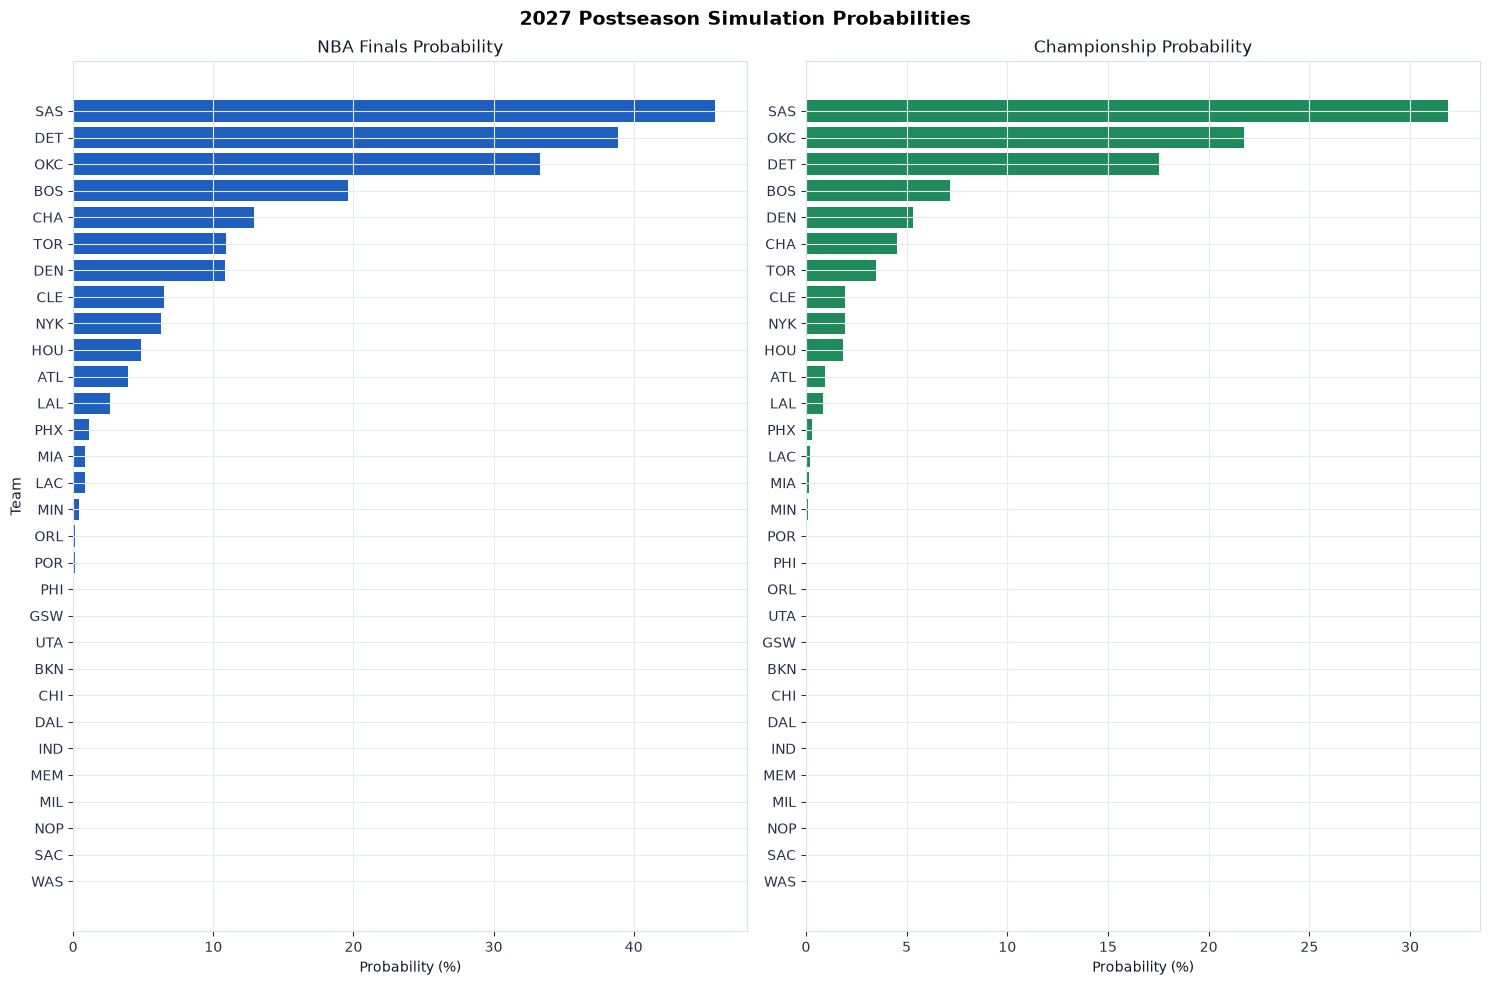

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

finals_rows = playoffs.sort_values("NBA_FINALS_PROB", ascending=True)
axes[0].barh(finals_rows["TEAM"], finals_rows["NBA_FINALS_PROB"] * 100, color="#1f5fbf")
axes[0].set_title("NBA Finals Probability")
axes[0].set_xlabel("Probability (%)")
axes[0].set_ylabel("Team")

championship_rows = playoffs.sort_values("CHAMPIONSHIP_PROB", ascending=True)
axes[1].barh(championship_rows["TEAM"], championship_rows["CHAMPIONSHIP_PROB"] * 100, color="#1f8a5b")
axes[1].set_title("Championship Probability")
axes[1].set_xlabel("Probability (%)")
axes[1].set_ylabel("")

fig.suptitle("2027 Postseason Simulation Probabilities", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


## 10. Final Forecast Summary

The summary file provides the headline forecast outputs used by the frontend dashboard.

In [22]:
with open(SUMMARY_PATH, "r") as file:
    summary = json.load(file)

highest_wins = summary["highest_projected_regular_season_win_total"]
summary_table = pd.DataFrame(
    [
        ["Projected East #1 seed", summary["projected_eastern_conference_1_seed"]],
        ["Projected West #1 seed", summary["projected_western_conference_1_seed"]],
        ["Highest projected regular-season wins", f"{highest_wins['team']} - {highest_wins['projected_wins']} wins"],
        ["Projected Eastern champion", summary["most_likely_eastern_conference_champion"]],
        ["Projected Western champion", summary["most_likely_western_conference_champion"]],
        ["Projected NBA champion", summary["most_likely_nba_champion"]],
        ["Championship probability", f"{summary['championship_probability'] * 100:.2f}%"],
    ],
    columns=["Forecast item", "Value"],
)

summary_table


,Forecast item,Value
0,Projected East #1 seed,DET
1,Projected West #1 seed,SAS
2,Highest projected regular-season wins,SAS - 59 wins
3,Projected Eastern champion,DET
4,Projected Western champion,SAS
5,Projected NBA champion,SAS
6,Championship probability,31.88%


## 11. Original vs. Final Model Improvement

The final model improved over the original model and was evaluated using a stronger chronological holdout design. The original metrics below are the reference values from the earlier project stage.

In [23]:
previous_metrics = {
    "Accuracy": 0.615,
    "ROC AUC": 0.672,
    "Log Loss": 0.649,
}

final_metrics = {
    "Accuracy": float(logistic_row["ACCURACY"]),
    "ROC AUC": float(logistic_row["ROC_AUC"]),
    "Log Loss": float(logistic_row["LOG_LOSS"]),
    "Brier Score": float(logistic_row["BRIER_SCORE"]),
}

improvement_rows = []
for metric in ["Accuracy", "ROC AUC", "Log Loss", "Brier Score"]:
    previous_value = previous_metrics.get(metric)
    final_value = final_metrics[metric]

    if previous_value is None:
        improvement = np.nan
        note = "No previous reference"
    elif metric == "Log Loss":
        improvement = previous_value - final_value
        note = "Lower is better"
    else:
        improvement = final_value - previous_value
        note = "Higher is better"

    improvement_rows.append(
        {
            "Metric": metric,
            "Previous best": previous_value,
            "Final Logistic Regression": final_value,
            "Improvement": improvement,
            "Interpretation": note,
        }
    )

improvement_table = pd.DataFrame(improvement_rows)
display(improvement_table.round(4))
display(Markdown(
    "The final evaluation is stronger methodologically because the entire 2025-26 season was reserved as an unseen chronological holdout rather than using a random split."
))


,Metric,Previous best,Final Logistic Regression,Improvement,Interpretation
0,Accuracy,0.615,0.6629,0.0479,Higher is better
1,ROC AUC,0.672,0.7240,0.0520,Higher is better
2,Log Loss,0.649,0.6102,0.0388,Lower is better
3,Brier Score,NaN,0.2106,NaN,No previous reference


The final evaluation is stronger methodologically because the entire 2025-26 season was reserved as an unseen chronological holdout rather than using a random split.

## 12. Limitations

- Injuries are not directly modeled.
- Every offseason roster transaction is not fully modeled.
- Preseason team states are primarily derived from completed 2025-26 team performance.
- Regular-season projections are team-strength estimates, not official-schedule simulations.
- Postseason simulations are conditional on the projected standings.
- Predictions are probabilistic, not guarantees.
- Performance on the 2025-26 holdout does not guarantee identical future performance.

## 13. Final Conclusion

This completed project combines NBA data collection, data cleaning, leakage-safe feature engineering, chronological model validation, probability-based model selection, Monte Carlo postseason simulation, production model inference, scheduled-game prediction, and frontend visualization.

The final forecast is strongest as a transparent probability system: it does not claim certainty, but it turns historical team performance into evaluated game probabilities, projected standings, and postseason championship odds that can be inspected and updated as better inputs become available.